In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from scipy.stats import mode
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV

Dataset description

In [2]:
dataset=pd.read_csv("/content/consumer_classification_dataset - consumer_classification_dataset.csv")
dataset

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
0,56.0,70201.18968,Female,Married,687.761776,9,12,Desktop,0
1,69.0,51901.89740,Male,Single,712.617115,3,14,Tablet,0
2,46.0,38605.40929,Male,Married,782.299643,5,8,Mobile,0
3,32.0,49949.73696,Female,Single,697.749518,7,1,Tablet,0
4,NaN,48965.29009,Other,Married,663.155216,4,4,Desktop,1
...,...,...,...,...,...,...,...,...,...
1495,40.0,38575.31141,Male,Single,717.997517,3,9,Mobile,0
1496,54.0,47273.37086,Other,Single,678.621530,4,2,Desktop,1
1497,28.0,52600.12136,Other,Divorced,611.316046,2,3,Desktop,0
1498,23.0,63187.64452,Female,Divorced,690.256745,5,7,Tablet,1


In [3]:
print("Shape (rows, cols):", dataset.shape)
print("Number of features:", dataset.shape[1]-1)
print("Number of data points:", dataset.shape[0])

Shape (rows, cols): (1500, 9)
Number of features: 8
Number of data points: 1500


In [4]:
target = "Churn"
if pd.api.types.is_numeric_dtype(dataset[target]) and dataset[target].nunique() > 20:
    print("Regression problem (continuous target).")
else:
    print("Classification problem (discrete target).")

Classification problem (discrete target).


In [5]:
num_cols = dataset.select_dtypes(include="number").columns.tolist()
cat_cols = dataset.select_dtypes(exclude="number").columns.tolist()
print("Quantitative features:", num_cols)
print("Categorical features:", cat_cols)

Quantitative features: ['Age', 'Income', 'Credit_Score', 'Num_Purchases', 'Membership_Years', 'Churn']
Categorical features: ['Gender', 'Marital_Status', 'Device_Used']


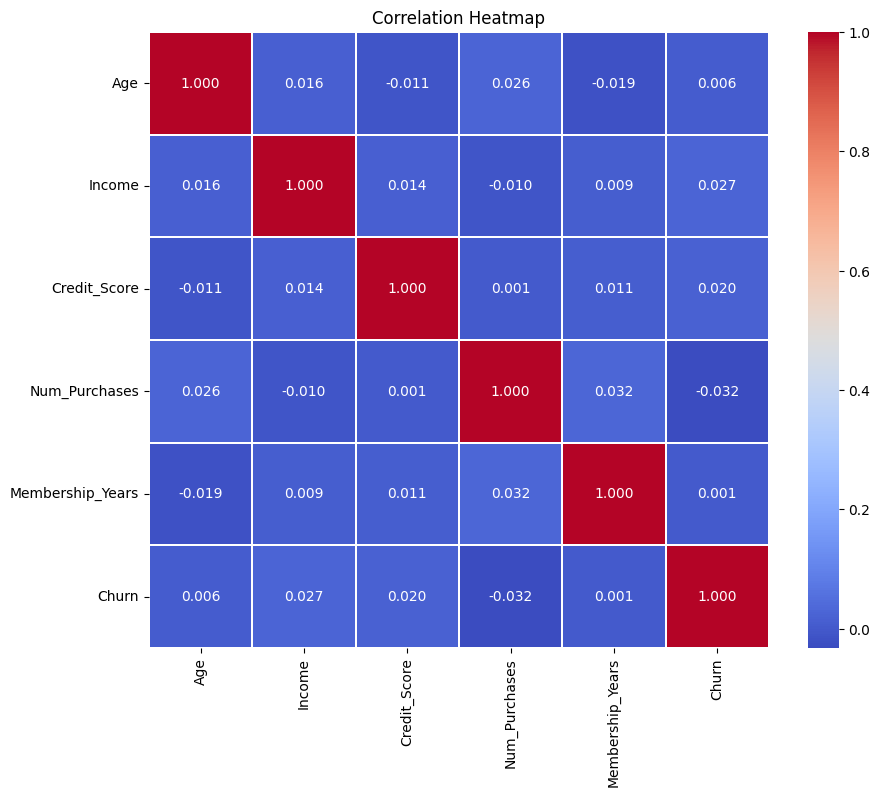

In [6]:
corr = dataset[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.title("Correlation Heatmap")
plt.show()

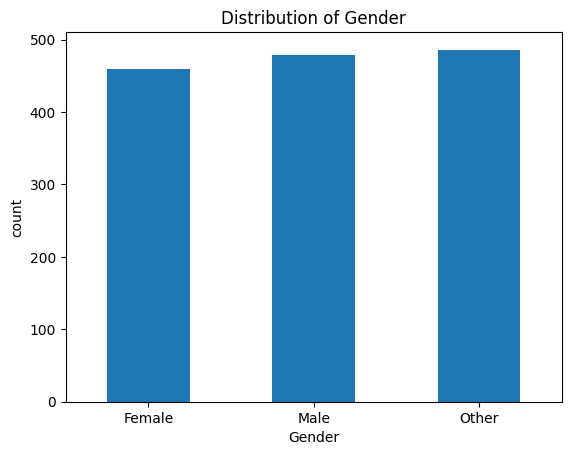

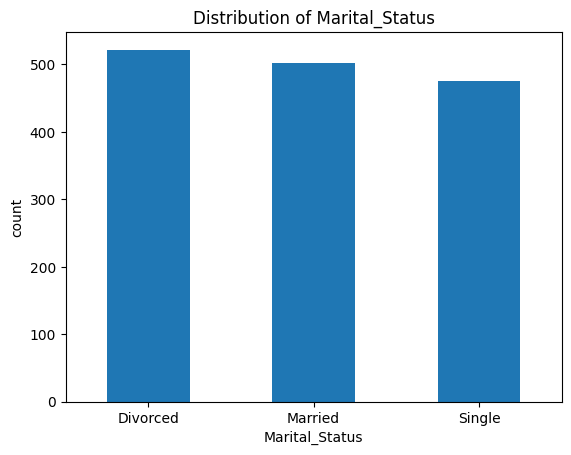

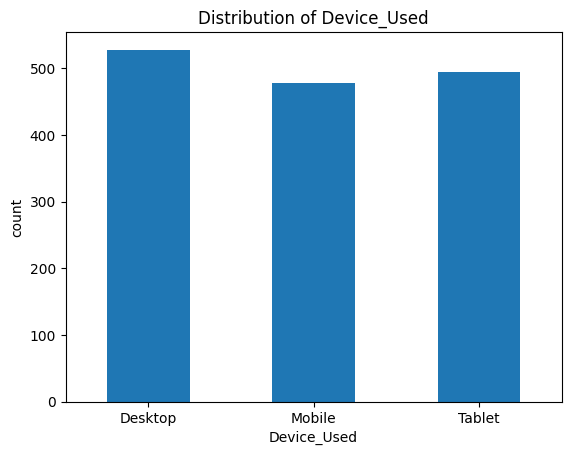

In [7]:
for col in cat_cols:
    plt.title(f'Distribution of {col}')
    dataset[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

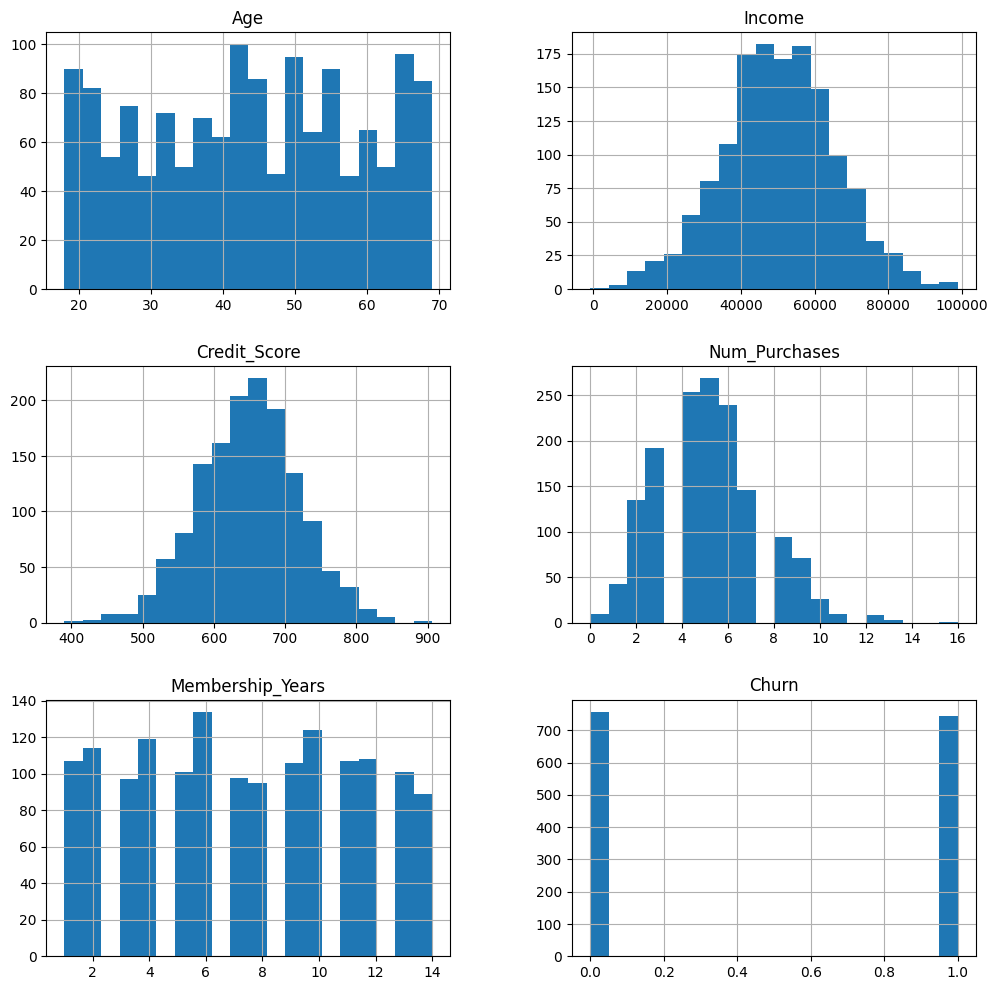

In [8]:
dataset[num_cols].hist(figsize=(12,12),bins=20)
plt.show()

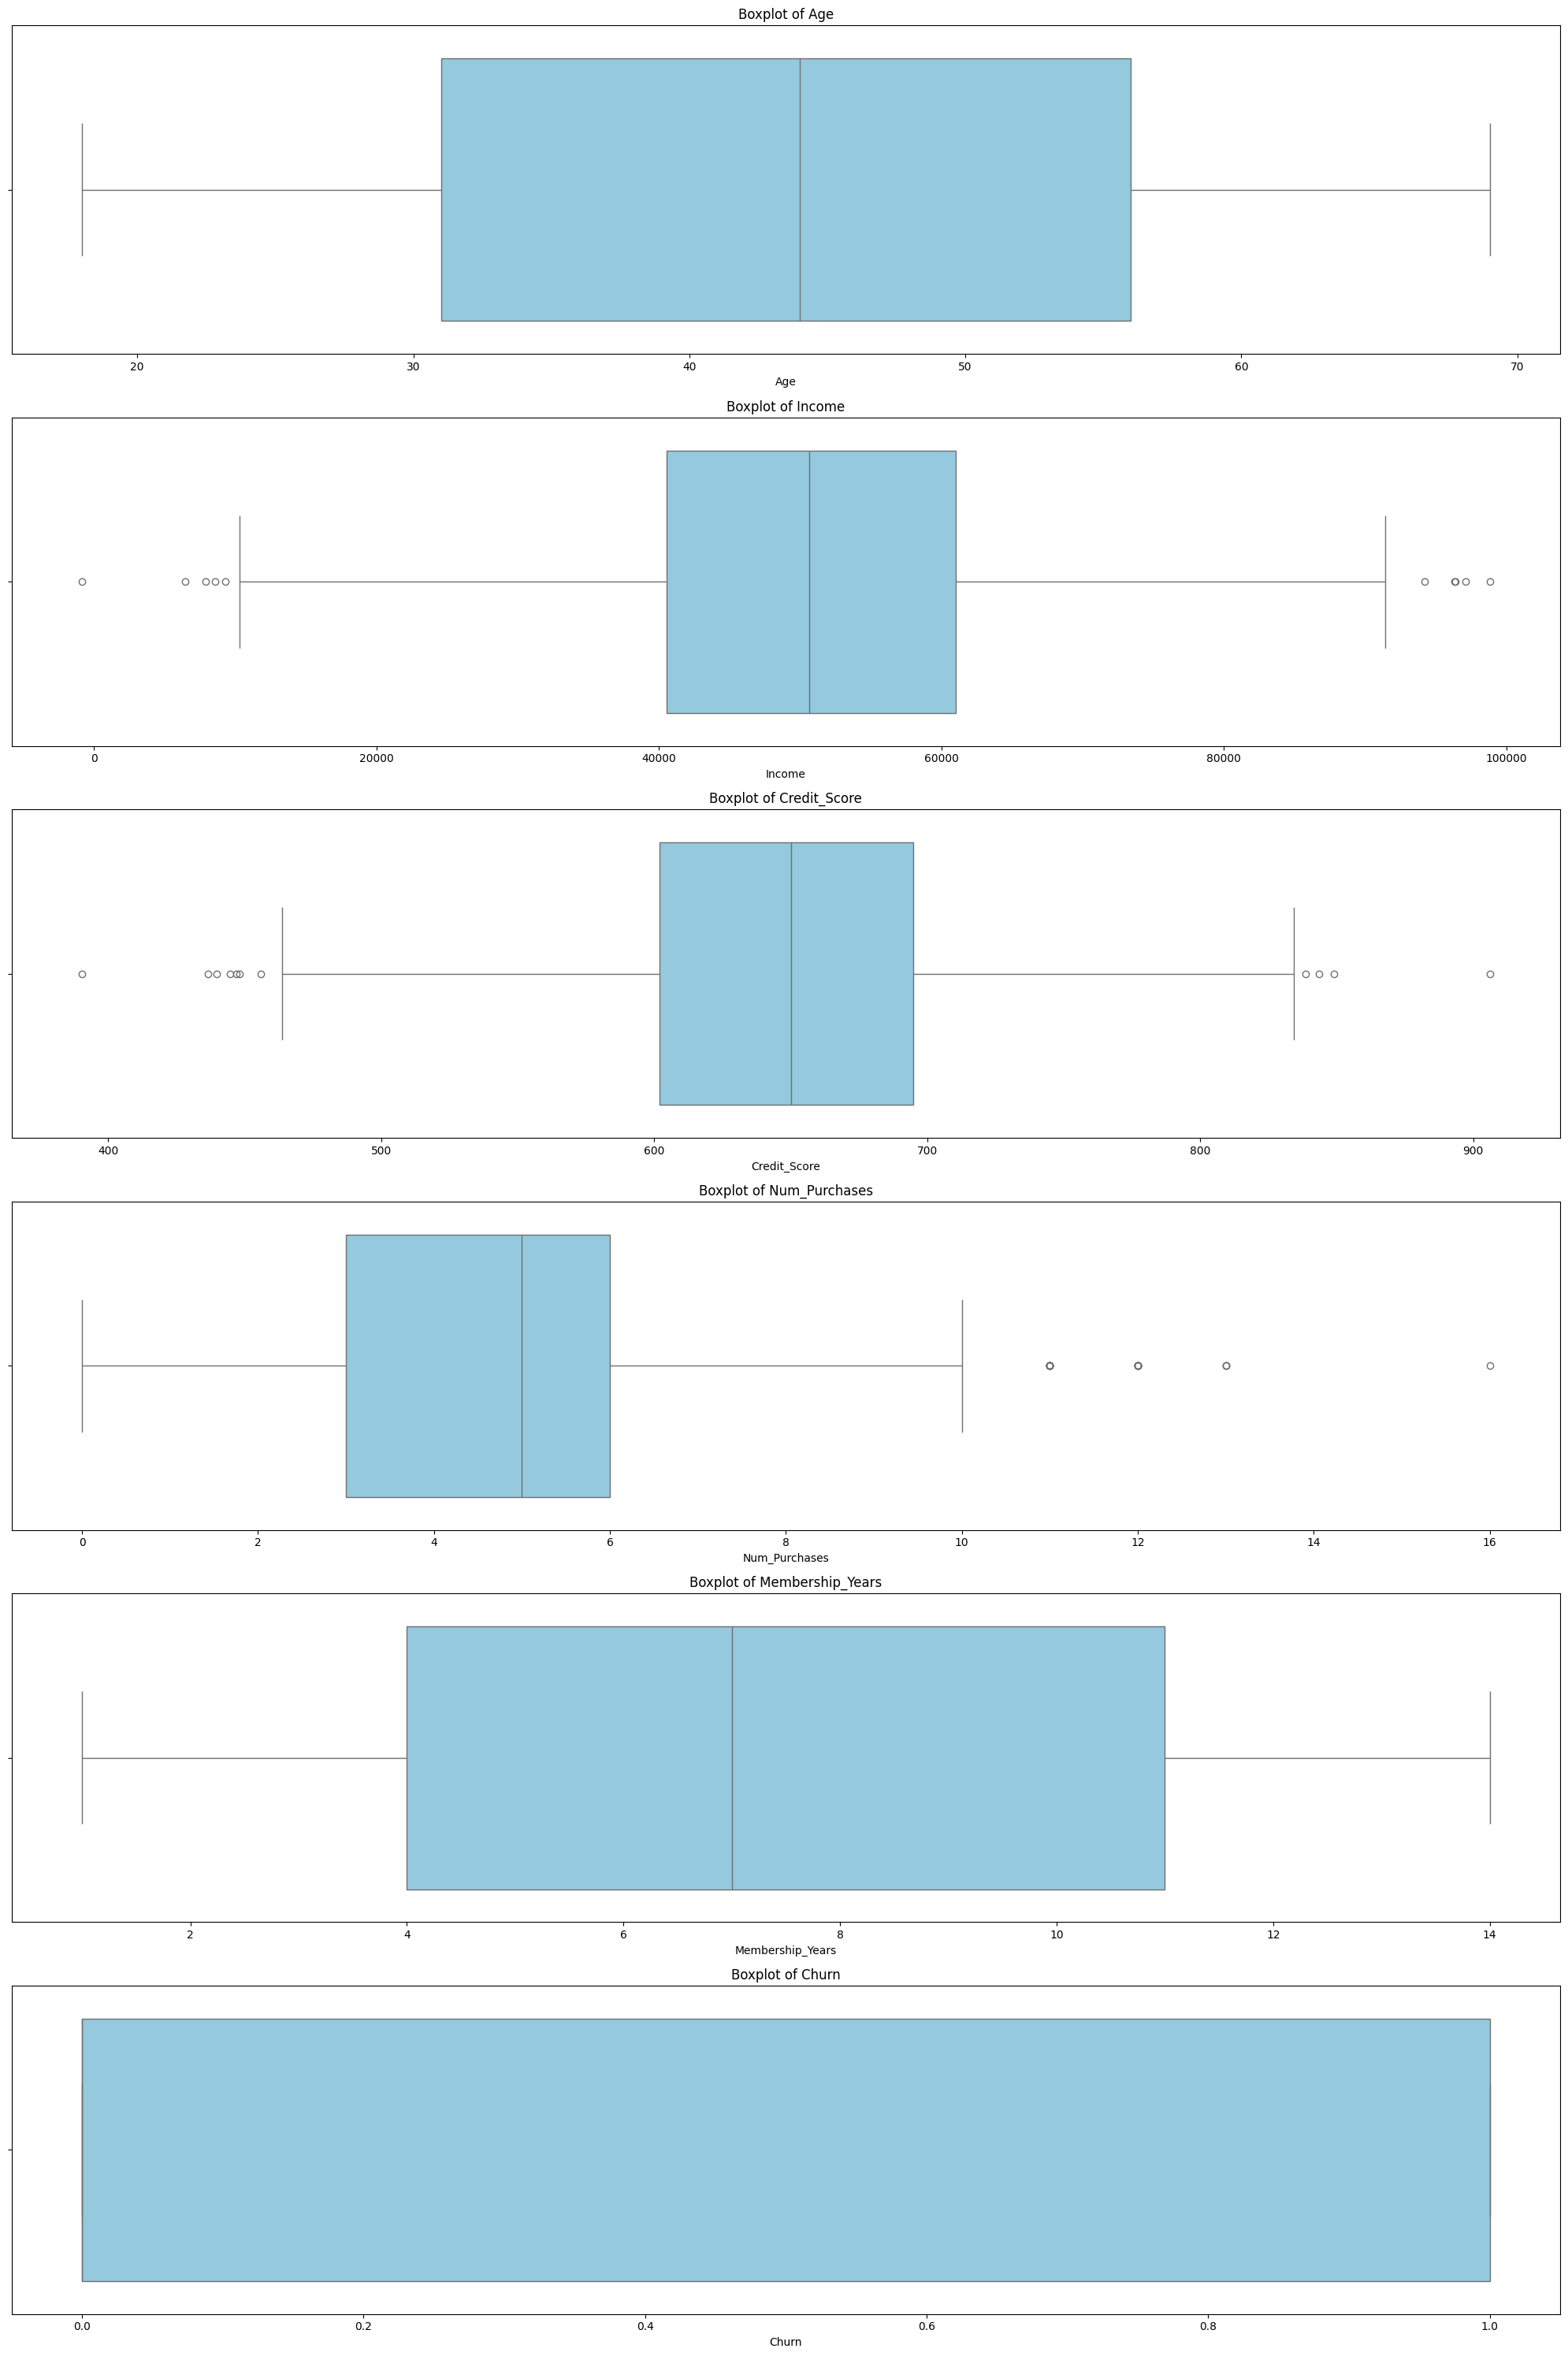

In [9]:
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20, 30))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()
plt.show()

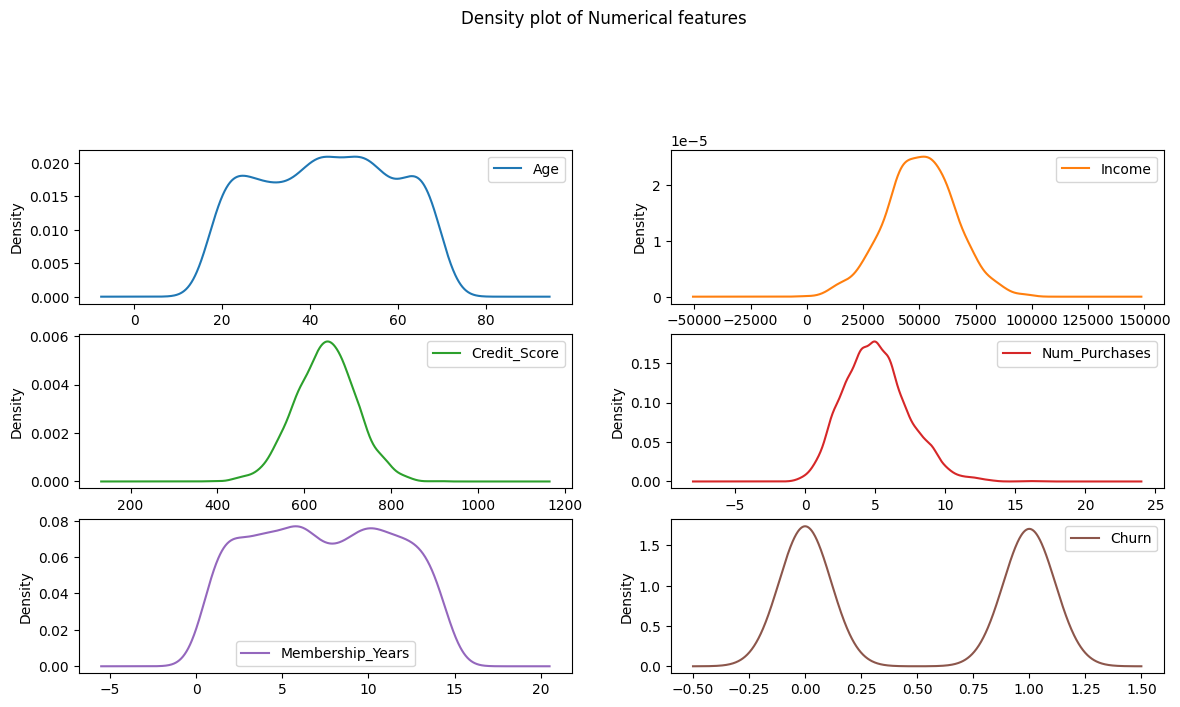

In [10]:
dataset[num_cols].plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

Dataset pre-processing

In [11]:
dataset.isnull().sum()

,0
Age,75
Income,75
Gender,75
Marital_Status,0
Credit_Score,75
Num_Purchases,0
Membership_Years,0
Device_Used,0
Churn,0


In [12]:
dataset.loc[(dataset['Age'] < 0) | (dataset['Age'] > 120), 'Age'] = np.nan
dataset.loc[(dataset['Credit_Score'] < 300) | (dataset['Credit_Score'] > 850), 'Credit_Score'] = np.nan
dataset.loc[dataset['Membership_Years'] < 0, 'Membership_Years'] = np.nan

In [13]:
num_imputer = KNNImputer(n_neighbors=3)
dataset[num_cols] = num_imputer.fit_transform(dataset[num_cols])

In [14]:
cat_imputer = SimpleImputer(strategy='most_frequent')
dataset[cat_cols] = cat_imputer.fit_transform(dataset[cat_cols])

In [15]:
dataset.isnull().sum()

,0
Age,0
Income,0
Gender,0
Marital_Status,0
Credit_Score,0
Num_Purchases,0
Membership_Years,0
Device_Used,0
Churn,0


In [16]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = ohe.fit_transform(dataset[cat_cols])
encoded_dataset = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(cat_cols))
dataset_encoded = dataset.drop(columns=cat_cols).reset_index(drop=True)
dataset_encoded = pd.concat([dataset_encoded, encoded_dataset.reset_index(drop=True)], axis=1)

In [17]:
dataset_encoded

,Age,Income,Credit_Score,Num_Purchases,Membership_Years,Churn,Gender_Female,Gender_Male,Gender_Other,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Device_Used_Desktop,Device_Used_Mobile,Device_Used_Tablet
0,56.0,70201.18968,687.761776,9.0,12.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,69.0,51901.89740,712.617115,3.0,14.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,46.0,38605.40929,782.299643,5.0,8.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,32.0,49949.73696,697.749518,7.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,53.0,48965.29009,663.155216,4.0,4.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,40.0,38575.31141,717.997517,3.0,9.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1496,54.0,47273.37086,678.621530,4.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1497,28.0,52600.12136,611.316046,2.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1498,23.0,63187.64452,690.256745,5.0,7.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [18]:
scaler = MinMaxScaler()
dataset_encoded[num_cols] = scaler.fit_transform(dataset_encoded[num_cols])

In [19]:
dataset_encoded

,Age,Income,Credit_Score,Num_Purchases,Membership_Years,Churn,Gender_Female,Gender_Male,Gender_Other,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Device_Used_Desktop,Device_Used_Mobile,Device_Used_Tablet
0,0.745098,0.712798,0.648619,0.5625,0.846154,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1.000000,0.529156,0.702832,0.1875,1.000000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.549020,0.395719,0.854819,0.3125,0.538462,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.274510,0.509565,0.670404,0.4375,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.686275,0.499685,0.594949,0.2500,0.230769,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.431373,0.395417,0.714567,0.1875,0.615385,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1496,0.705882,0.482706,0.628683,0.2500,0.076923,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1497,0.196078,0.536163,0.481881,0.1250,0.153846,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1498,0.098039,0.642414,0.654061,0.3125,0.461538,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [20]:
feature_variances = dataset_encoded.drop(columns=['Churn']).var()
low_variance_cols = feature_variances[feature_variances < 0.001].index.tolist()
print("\n" + "="*60)
print("LOW-VARIANCE FEATURES (variance < 0.001)")
print("-"*60)
if low_variance_cols:
    for col in low_variance_cols:
        print(f"{col:<30} | Variance: {feature_variances[col]:.6f}")
else:
    print("No features meet the low-variance criteria.")
print("="*60 + "\n")
corr_with_target = dataset_encoded.corr()['Churn'].abs()
low_corr_cols = [col for col in corr_with_target.index if col != 'Churn' and corr_with_target[col] < 0.02]
print("="*60)
print("LOW-CORRELATION FEATURES (correlation with Churn < 0.02)")
print("-"*60)
if low_corr_cols:
    for col in low_corr_cols:
        print(f"{col:<30} | Correlation: {corr_with_target[col]:.6f}")
else:
    print("No features meet the low-correlation criteria.")
print("="*60 + "\n")
noisy_cols = list(set(low_variance_cols + low_corr_cols))


LOW-VARIANCE FEATURES (variance < 0.001)
------------------------------------------------------------
No features meet the low-variance criteria.

LOW-CORRELATION FEATURES (correlation with Churn < 0.02)
------------------------------------------------------------
Age                            | Correlation: 0.005962
Income                         | Correlation: 0.019619
Membership_Years               | Correlation: 0.001416
Gender_Female                  | Correlation: 0.000424
Gender_Male                    | Correlation: 0.006477
Gender_Other                   | Correlation: 0.005837
Marital_Status_Divorced        | Correlation: 0.009977
Device_Used_Tablet             | Correlation: 0.017889



In [21]:
drop_cols = noisy_cols
dataset_encoded = dataset_encoded.drop(columns = drop_cols)

In [22]:
dataset_encoded

,Credit_Score,Num_Purchases,Churn,Marital_Status_Married,Marital_Status_Single,Device_Used_Desktop,Device_Used_Mobile
0,0.648619,0.5625,0.0,1.0,0.0,1.0,0.0
1,0.702832,0.1875,0.0,0.0,1.0,0.0,0.0
2,0.854819,0.3125,0.0,1.0,0.0,0.0,1.0
3,0.670404,0.4375,0.0,0.0,1.0,0.0,0.0
4,0.594949,0.2500,1.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...
1495,0.714567,0.1875,0.0,0.0,1.0,0.0,1.0
1496,0.628683,0.2500,1.0,0.0,1.0,1.0,0.0
1497,0.481881,0.1250,0.0,0.0,0.0,1.0,0.0
1498,0.654061,0.3125,1.0,0.0,0.0,0.0,0.0


Dataset splitting

In [23]:
X = dataset_encoded.drop(columns=["Churn"])
y = dataset_encoded["Churn"]
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, random_state=42, stratify=y_trainval
)

In [24]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1049, 6)
Validation: (226, 6)
Test: (225, 6)


In [25]:
def print_churn_distribution(y, set_name):
    counts = y.value_counts()
    percentages = y.value_counts(normalize=True) * 100
    print(f"\nChurn distribution in {set_name} set:")
    print("-------------------------------")
    for cls in counts.index:
        print(f"Churn={cls}: {counts[cls]} samples ({percentages[cls]:.2f}%)")
    print("-------------------------------")

In [26]:
print_churn_distribution(y_train, "Train")
print_churn_distribution(y_val, "Validation")
print_churn_distribution(y_test, "Test")


Churn distribution in Train set:
-------------------------------
Churn=0.0: 529 samples (50.43%)
Churn=1.0: 520 samples (49.57%)
-------------------------------

Churn distribution in Validation set:
-------------------------------
Churn=0.0: 114 samples (50.44%)
Churn=1.0: 112 samples (49.56%)
-------------------------------

Churn distribution in Test set:
-------------------------------
Churn=0.0: 114 samples (50.67%)
Churn=1.0: 111 samples (49.33%)
-------------------------------


Model training & testing (Supervised)

In [27]:
param_dist = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn = KNeighborsClassifier()
random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)
best_knn = random_search.best_estimator_
best_knn.fit(X_train, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=30)

In [28]:
y_val_pred = best_knn.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print("\n" + "="*40)
print("VALIDATION RESULTS (KNN)")
print("="*40)
print(f"Accuracy: {val_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_val_pred))
print("-"*40)
y_test_pred = best_knn.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print("\n" + "="*40)
print("TEST RESULTS (KNN)")
print("="*40)
print(f"Accuracy: {test_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("="*40)


VALIDATION RESULTS (KNN)
Accuracy: 0.4690

Classification Report:
              precision    recall  f1-score   support

         0.0       0.48      0.63      0.55       114
         1.0       0.45      0.30      0.36       112

    accuracy                           0.47       226
   macro avg       0.46      0.47      0.45       226
weighted avg       0.46      0.47      0.45       226

----------------------------------------

TEST RESULTS (KNN)
Accuracy: 0.5333

Classification Report:
              precision    recall  f1-score   support

         0.0       0.53      0.66      0.59       114
         1.0       0.54      0.41      0.46       111

    accuracy                           0.53       225
   macro avg       0.53      0.53      0.52       225
weighted avg       0.53      0.53      0.53       225

Confusion Matrix:
[[75 39]
 [66 45]]


In [29]:
param_dist = {
    'max_depth': [None] + list(range(2, 21)),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}
dtree = DecisionTreeClassifier(random_state=42)
random_search = RandomizedSearchCV(
    estimator=dtree,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)
best_dtree = random_search.best_estimator_
best_dtree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, max_features='log2',
                       min_samples_leaf=2, min_samples_split=10,
                       random_state=42)

In [30]:
y_val_pred = best_dtree.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print("\n" + "="*40)
print("VALIDATION RESULTS (Decision Tree)")
print("="*40)
print(f"Accuracy: {val_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_val_pred))
print("-"*40)
y_test_pred = best_dtree.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print("\n" + "="*40)
print("TEST RESULTS (Decision Tree)")
print("="*40)
print(f"Accuracy: {test_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("="*40)


VALIDATION RESULTS (Decision Tree)
Accuracy: 0.5310

Classification Report:
              precision    recall  f1-score   support

         0.0       0.53      0.54      0.54       114
         1.0       0.53      0.52      0.52       112

    accuracy                           0.53       226
   macro avg       0.53      0.53      0.53       226
weighted avg       0.53      0.53      0.53       226

----------------------------------------

TEST RESULTS (Decision Tree)
Accuracy: 0.5244

Classification Report:
              precision    recall  f1-score   support

         0.0       0.53      0.54      0.53       114
         1.0       0.52      0.51      0.52       111

    accuracy                           0.52       225
   macro avg       0.52      0.52      0.52       225
weighted avg       0.52      0.52      0.52       225

Confusion Matrix:
[[61 53]
 [54 57]]


In [31]:
param_dist = {
    'hidden_layer_sizes': [(32,), (64,), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001]
}
nn = MLPClassifier(
    max_iter=500,
    early_stopping=True,
    random_state=42
)
random_search = RandomizedSearchCV(
    estimator=nn,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)
best_nn = random_search.best_estimator_
best_nn.fit(X_train, y_train)

MLPClassifier(alpha=0.001, early_stopping=True, hidden_layer_sizes=(64,),
              max_iter=500, random_state=42)

In [32]:
y_val_pred = best_nn.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print("\n" + "="*40)
print("VALIDATION RESULTS (Neural Network)")
print("="*40)
print(f"Accuracy: {val_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_val_pred))
print("-"*40)
y_test_pred = best_nn.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print("\n" + "="*40)
print("TEST RESULTS (Neural Network)")
print("="*40)
print(f"Accuracy: {test_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("="*40)


VALIDATION RESULTS (Neural Network)
Accuracy: 0.4956

Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      0.51      0.50       114
         1.0       0.49      0.48      0.49       112

    accuracy                           0.50       226
   macro avg       0.50      0.50      0.50       226
weighted avg       0.50      0.50      0.50       226

----------------------------------------

TEST RESULTS (Neural Network)
Accuracy: 0.5244

Classification Report:
              precision    recall  f1-score   support

         0.0       0.53      0.51      0.52       114
         1.0       0.52      0.54      0.53       111

    accuracy                           0.52       225
   macro avg       0.52      0.52      0.52       225
weighted avg       0.52      0.52      0.52       225

Confusion Matrix:
[[58 56]
 [51 60]]


In [33]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

In [34]:
sil_score = silhouette_score(X, clusters)
print("\n" + "="*40)
print("K-MEANS CLUSTERING RESULTS")
print("="*40)
print(f"Silhouette Score: {sil_score:.4f}\n")
cm = confusion_matrix(y, clusters)
print("Confusion Matrix between clusters and actual churn:")
print("-"*40)
print(cm)
print("-"*40)
import numpy as np
cluster_counts = np.bincount(clusters)
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} samples ({count/len(clusters)*100:.2f}%)")
print("="*40)


K-MEANS CLUSTERING RESULTS
Silhouette Score: 0.3235

Confusion Matrix between clusters and actual churn:
----------------------------------------
[[229 528]
 [249 494]]
----------------------------------------
Cluster 0: 478 samples (31.87%)
Cluster 1: 1022 samples (68.13%)


Model selection/Comparison analysis

In [35]:
models = {
    "KNN": best_knn,
    "Decision Tree": best_dtree,
    "Neural Network": best_nn,
    "KMeans": kmeans
}
results = {}

In [36]:
for name, model in models.items():
    if name != "KMeans":
      y_pred = model.predict(X_test)
      y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else y_pred
      results[name] = {
          "accuracy": accuracy_score(y_test, y_pred),
          "precision": precision_score(y_test, y_pred, zero_division=0),
          "recall": recall_score(y_test, y_pred, zero_division=0),
          "f1": f1_score(y_test, y_pred, zero_division=0),
          "conf_matrix": confusion_matrix(y_test, y_pred),
          "roc_auc": roc_auc_score(y_test, y_prob) if hasattr(model, "predict_proba") else np.nan,
          "fpr": roc_curve(y_test, y_prob)[0] if hasattr(model, "predict_proba") else None,
          "tpr": roc_curve(y_test, y_prob)[1] if hasattr(model, "predict_proba") else None
      }

In [37]:
labels_map = {}
for cluster in np.unique(kmeans.labels_):
    mask = kmeans.labels_ == cluster
    labels_map[cluster] = mode(y[mask], keepdims=True).mode[0]
y_pred_kmeans = np.vectorize(labels_map.get)(kmeans.predict(X_test))
results["KMeans"] = {
    "accuracy": accuracy_score(y_test, y_pred_kmeans),
    "precision": precision_score(y_test, y_pred_kmeans, zero_division=0),
    "recall": recall_score(y_test, y_pred_kmeans, zero_division=0),
    "f1": f1_score(y_test, y_pred_kmeans, zero_division=0),
    "conf_matrix": confusion_matrix(y_test, y_pred_kmeans),
    "roc_auc": np.nan,
    "fpr": None,
    "tpr": None
}

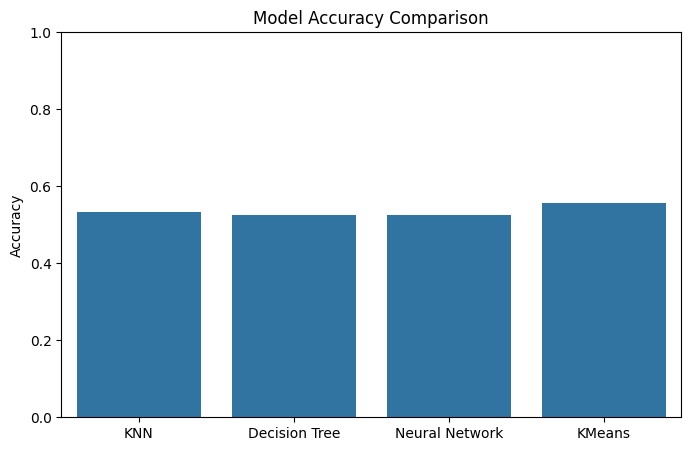

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=[v["accuracy"] for v in results.values()])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

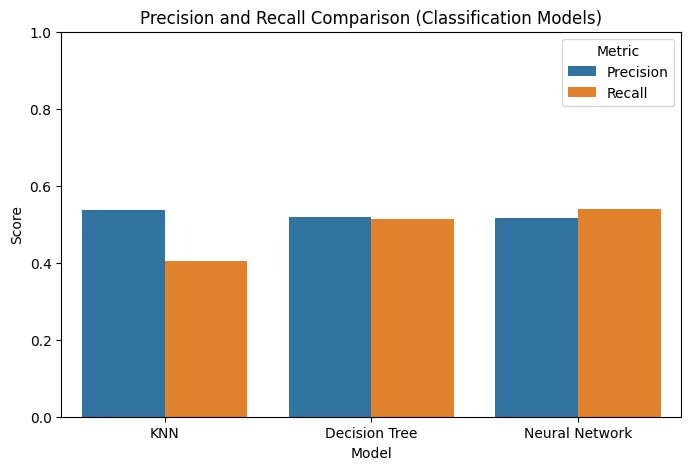

In [39]:
metrics_df = {"Model": [], "Metric": [], "Score": []}
for name, v in results.items():
    if name != "KMeans":
        for metric in ["precision", "recall"]:
          metrics_df["Model"].append(name)
          metrics_df["Metric"].append(metric.capitalize())
          metrics_df["Score"].append(v[metric])
metrics_df = pd.DataFrame(metrics_df)
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Score", hue="Metric", data=metrics_df)
plt.title("Precision and Recall Comparison (Classification Models)")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.show()

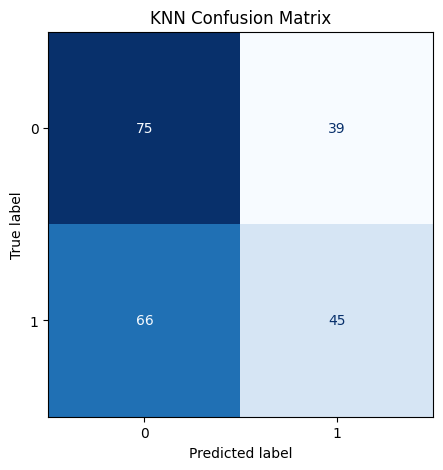

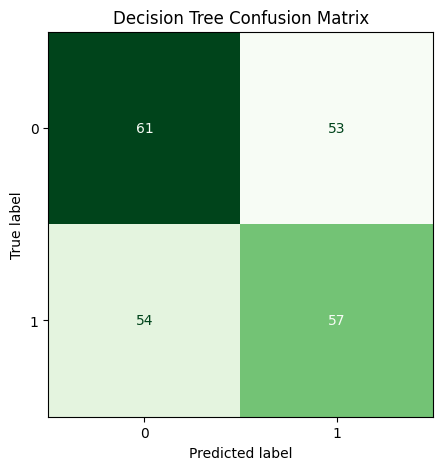

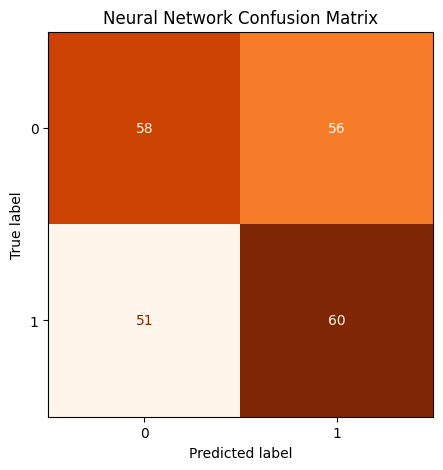

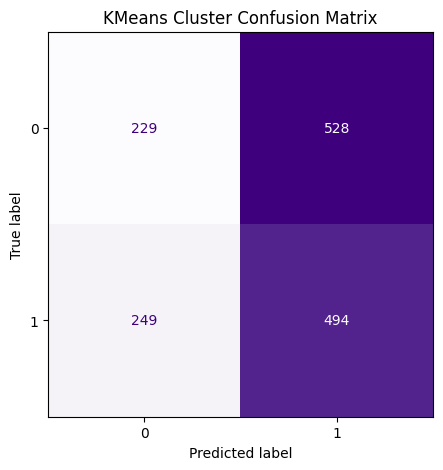

In [40]:
cm_knn = confusion_matrix(y_test, best_knn.predict(X_test))
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay(cm_knn).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("KNN Confusion Matrix")
plt.show()
cm_tree = confusion_matrix(y_test, best_dtree.predict(X_test))
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay(cm_tree).plot(cmap="Greens", ax=ax, colorbar=False)
ax.set_title("Decision Tree Confusion Matrix")
plt.show()
cm_nn = confusion_matrix(y_test, best_nn.predict(X_test))
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay(cm_nn).plot(cmap="Oranges", ax=ax, colorbar=False)
ax.set_title("Neural Network Confusion Matrix")
plt.show()
cm_raw = confusion_matrix(y, clusters)
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay(cm_raw).plot(cmap="Purples", ax=ax, colorbar=False)
ax.set_title("KMeans Cluster Confusion Matrix")
plt.show()

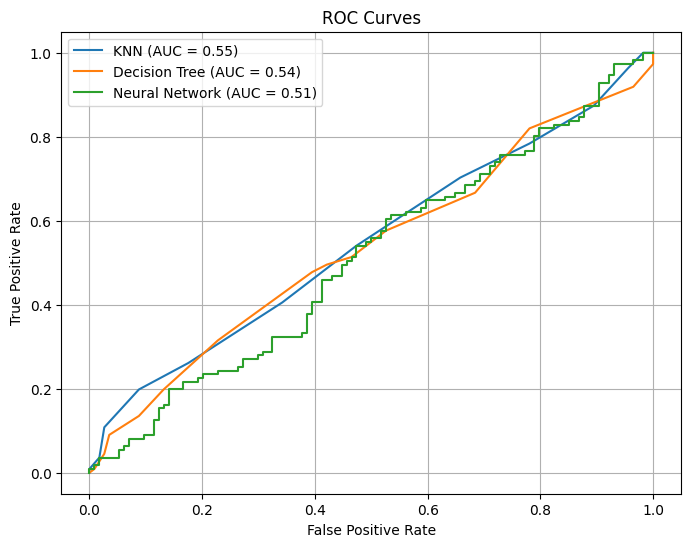

In [41]:
plt.figure(figsize=(8,6))
for name, v in results.items():
    if v["fpr"] is not None:
        plt.plot(v["fpr"], v["tpr"], label=f"{name} (AUC = {v['roc_auc']:.2f})")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()